# Michelin Star Allocation — Negative Binomial Regression
### Starred and Questioned: Capstone Project

**Research Question:** Are Michelin stars efficiently allocated across global markets in 2026 given economic, geographic, and market constraints?

**Why Negative Binomial?**
Our dependent variable — total starred restaurants per country — is a non-negative integer count. The distribution is heavily overdispersed (France has 669 stars, Saudi Arabia has 0, mean = 81, std = 135). OLS would produce biased predictions and potentially negative fitted values. Poisson regression assumes variance equals the mean, which this data violates badly. Negative Binomial relaxes that assumption by estimating a dispersion parameter alpha, making it the appropriate model for overdispersed count outcomes.

**Note on implementation:** We implement NB2 directly via maximum likelihood using `scipy.optimize` since `statsmodels` is not available in this environment. The math is identical to what statsmodels computes under the hood.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import norm as zdist
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.facecolor'] = '#f8f8f6'
plt.rcParams['axes.facecolor']   = '#f8f8f6'
plt.rcParams['font.family']      = 'sans-serif'

## 1. Load Data & Initial Inspection

The model dataset was built by:
1. Scraping the full Michelin Guide 2026 via the Algolia API (18,837 restaurants)
2. Compiling external variables for 47 countries: GDP per capita (World Bank / IMF), urbanization rate (World Bank), inbound tourism arrivals (UNWTO), and restaurant counts (Eurostat NACE 56.1 equivalent)
3. Collapsing the restaurant-level data to one row per country with star counts, pricing composition, and derived density ratios
4. Merging with external variables

Absorbed territories: Andorra + Monaco → France, Liechtenstein → Switzerland, Hong Kong + Macao → combined row.

In [3]:
df = pd.read_csv('michelin_country_model_dataset.csv')
print(f"Shape: {df.shape}")
print(f"Countries: {df['country'].nunique()}")
print()

# Key columns we need
key_cols = ['country', 'n_total_starred', 'gdp_per_capita_usd_2023',
            'restaurant_count', 'tourism_2023', 'urban_pct_2023',
            'median_price_floor_usd_starred']

print("Missing values in key columns:")
print(df[key_cols].isnull().sum())
print()
print("Summary of dependent variable (n_total_starred):")
print(df['n_total_starred'].describe().round(2))

Shape: (47, 44)
Countries: 47

Missing values in key columns:
country                           0
n_total_starred                   0
gdp_per_capita_usd_2023           0
restaurant_count                  0
tourism_2023                      0
urban_pct_2023                    0
median_price_floor_usd_starred    1
dtype: int64

Summary of dependent variable (n_total_starred):
count     47.00
mean      81.21
std      134.71
min        0.00
25%        9.00
50%       22.00
75%       86.50
max      669.00
Name: n_total_starred, dtype: float64


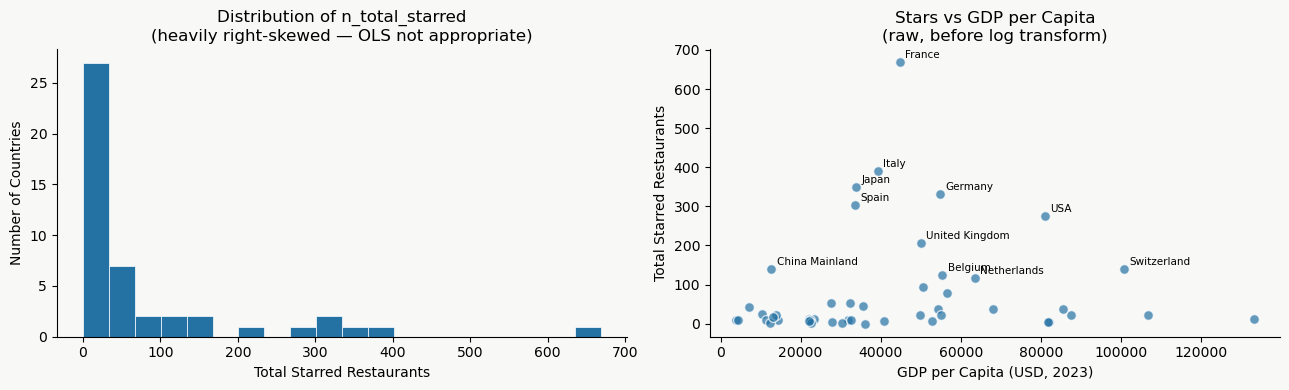

In [5]:
# Visualise the skew — this is why we need negative binomial not OLS
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['n_total_starred'], bins=20, color='#2471a3', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Total Starred Restaurants')
axes[0].set_ylabel('Number of Countries')
axes[0].set_title('Distribution of n_total_starred\n(heavily right-skewed — OLS not appropriate)')
axes[0].spines[['top','right']].set_visible(False)

axes[1].scatter(df['gdp_per_capita_usd_2023'], df['n_total_starred'],
                color='#2471a3', alpha=0.7, s=50, edgecolors='white')
for _, row in df[df['n_total_starred'] > 100].iterrows():
    axes[1].annotate(row['country'], (row['gdp_per_capita_usd_2023'], row['n_total_starred']),
                     fontsize=7.5, xytext=(4,3), textcoords='offset points')
axes[1].set_xlabel('GDP per Capita (USD, 2023)')
axes[1].set_ylabel('Total Starred Restaurants')
axes[1].set_title('Stars vs GDP per Capita\n(raw, before log transform)')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 2. Feature Engineering

Three transformations before modelling:

1. **Log-transform** GDP, restaurant count, and tourism — all three are heavily right-skewed and span orders of magnitude. Log makes the relationship approximately linear and stabilises the regression.
2. **Standardise** all predictors (z-score) — makes coefficients directly comparable in magnitude, which matters when comparing the relative importance of GDP vs tourism vs restaurant count.
3. **Fill the one missing value** — `median_price_floor_usd_starred` is null for Saudi Arabia (0 starred restaurants, so no starred price floor exists). We fill with the country's overall median price floor as a reasonable proxy.

In [7]:
# Fill Saudi Arabia's missing starred price floor with its overall median
df['median_price_floor_usd_starred'] = df['median_price_floor_usd_starred'].fillna(
    df['median_price_floor_usd_all']
)

# Log transforms
df['log_gdp']               = np.log(df['gdp_per_capita_usd_2023'])
df['log_restaurant_count']  = np.log(df['restaurant_count'])
df['log_tourism']           = np.log(df['tourism_2023'])

# Standardise
def standardise(s):
    return (s - s.mean()) / s.std()

df['z_log_gdp']          = standardise(df['log_gdp'])
df['z_log_restaurants']  = standardise(df['log_restaurant_count'])
df['z_log_tourism']      = standardise(df['log_tourism'])
df['z_urban']            = standardise(df['urban_pct_2023'])
df['z_price_floor']      = standardise(df['median_price_floor_usd_starred'])

print("Feature engineering complete. Transformed variables:")
print(df[['country','z_log_gdp','z_log_restaurants','z_log_tourism',
          'z_urban','z_price_floor']].head(8).round(3).to_string(index=False))

Feature engineering complete. Transformed variables:
       country  z_log_gdp  z_log_restaurants  z_log_tourism  z_urban  z_price_floor
     Argentina     -1.026              0.348         -0.622    1.046         -0.842
       Austria      0.661             -0.373          0.757   -0.627          0.194
       Belgium      0.633             -0.301         -0.311    0.708          0.194
        Brazil     -1.415              1.372         -0.810    0.713         -0.073
        Canada      0.609              0.250          0.261    0.342         -0.727
China Mainland     -1.177              3.004          0.889   -0.850         -1.167
       Croatia     -0.485             -0.587          0.392   -1.499          0.194
Czech Republic     -0.046             -0.200         -0.062   -0.371         -0.305


In [9]:
# Note on Saudi Arabia — structural zero
print("Saudi Arabia detail:")
print(df[df['country']=='Saudi Arabia'][['country','n_total_starred','total_listed',
                                         'gdp_per_capita_usd_2023','tourism_2023']].to_string(index=False))
print()
print("Saudi Arabia has 0 stars despite 51 listed restaurants.")
print("Michelin entered Saudi Arabia very recently and has awarded Bib Gourmands")
print("but no stars as of 2026. This is a structural zero — not a market that")
print("competes for stars and loses, but one not yet in the star-awarding pipeline.")
print("We run the model both with and without this observation as a robustness check.")

Saudi Arabia detail:
     country  n_total_starred  total_listed  gdp_per_capita_usd_2023  tourism_2023
Saudi Arabia                0            51                 36156.85      27000000

Saudi Arabia has 0 stars despite 51 listed restaurants.
Michelin entered Saudi Arabia very recently and has awarded Bib Gourmands
but no stars as of 2026. This is a structural zero — not a market that
competes for stars and loses, but one not yet in the star-awarding pipeline.
We run the model both with and without this observation as a robustness check.


## 3. Negative Binomial Regression — Model Definition

**NB2 Parameterisation:**

$$P(Y = y \mid \mu, \alpha) = \frac{\Gamma(y + 1/\alpha)}{\Gamma(1/\alpha)\, \Gamma(y+1)} \left(\frac{1/\alpha}{1/\alpha + \mu}\right)^{1/\alpha} \left(\frac{\mu}{1/\alpha + \mu}\right)^y$$

where $\mu_i = \exp(\mathbf{x}_i^\top \boldsymbol{\beta})$ and $\text{Var}(Y) = \mu + \alpha \mu^2$.

- When $\alpha \to 0$, NB2 reduces to Poisson
- A large $\alpha$ indicates the structural variables leave substantial unexplained variance — meaning something beyond GDP, restaurants, and tourism is at work
- We estimate $\log(\alpha)$ in the optimiser to keep $\alpha$ strictly positive

We maximise the log-likelihood via L-BFGS-B, then compute standard errors from the numerical Hessian of the negative log-likelihood at the optimum.

In [11]:
# ── Log-likelihood function ──────────────────────────────────────────────────
def negbin_loglik(params, y, X):
    """
    Negative Binomial NB2 log-likelihood (negated for minimisation).
    params: [beta_0, ..., beta_k, log_alpha]
    y: outcome count vector
    X: design matrix (n x k+1, first column is ones for intercept)
    """
    beta  = params[:-1]
    alpha = np.exp(params[-1])        # exp keeps alpha > 0 throughout optimisation
    r     = 1.0 / alpha               # NB shape parameter
    mu    = np.clip(np.exp(X @ beta), 1e-10, 1e10)

    ll = (gammaln(y + r)
          - gammaln(r)
          - gammaln(y + 1)
          + r * np.log(r / (r + mu))
          + y * np.log(mu / (r + mu)))

    return -ll.sum()  # minimise negative log-likelihood


# ── Design matrix builder ────────────────────────────────────────────────────
def build_X(data):
    """Returns design matrix with intercept + 5 standardised predictors."""
    return np.column_stack([
        np.ones(len(data)),
        data['z_log_gdp'].values,
        data['z_log_restaurants'].values,
        data['z_log_tourism'].values,
        data['z_urban'].values,
        data['z_price_floor'].values,
    ])

feature_names = ['Intercept', 'log_gdp (std)', 'log_restaurants (std)',
                 'log_tourism (std)', 'urban_pct (std)', 'price_floor_usd (std)']


# ── Fitting function ─────────────────────────────────────────────────────────
def fit_negbin(y, X):
    """Fit NB2 via L-BFGS-B. Returns scipy OptimizeResult."""
    init      = np.zeros(X.shape[1] + 1)
    init[-1]  = np.log(0.5)           # start with alpha = 0.5
    return minimize(
        fun     = negbin_loglik,
        x0      = init,
        args    = (y, X),
        method  = 'L-BFGS-B',
        options = {'maxiter': 3000, 'ftol': 1e-14, 'gtol': 1e-9}
    )


# ── Standard errors via numerical Hessian ────────────────────────────────────
def numerical_hessian(f, x0, eps=1e-4):
    """4-point finite-difference Hessian of f at x0."""
    n = len(x0)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            xpp = x0.copy(); xpp[i] += eps; xpp[j] += eps
            xpm = x0.copy(); xpm[i] += eps; xpm[j] -= eps
            xmp = x0.copy(); xmp[i] -= eps; xmp[j] += eps
            xmm = x0.copy(); xmm[i] -= eps; xmm[j] -= eps
            H[i, j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4 * eps**2)
            H[j, i] = H[i, j]
    return H

def get_se(result, y, X):
    """Standard errors from inverse Hessian of negative log-likelihood."""
    H   = numerical_hessian(lambda p: negbin_loglik(p, y, X), result.x)
    cov = np.linalg.inv(H)
    return np.sqrt(np.abs(np.diag(cov)))


print("Model functions defined. Ready to fit.")

Model functions defined. Ready to fit.


## 4. Fit Models

**Model A** — Full sample (n = 47 countries)  
**Model B** — Saudi Arabia excluded (n = 46) as primary robustness check

In [13]:
# ── Model A: full sample ─────────────────────────────────────────────────────
y_A = df['n_total_starred'].values.astype(float)
X_A = build_X(df)

print("Fitting Model A (n=47)...")
res_A = fit_negbin(y_A, X_A)
print(f"  Converged: {res_A.success}   Log-likelihood: {-res_A.fun:.4f}")

print("Computing standard errors...")
se_A  = get_se(res_A, y_A, X_A)

# ── Model B: Saudi Arabia excluded ──────────────────────────────────────────
df_B = df[df['country'] != 'Saudi Arabia'].reset_index(drop=True)
y_B  = df_B['n_total_starred'].values.astype(float)
X_B  = build_X(df_B)

print("\nFitting Model B (n=46, Saudi Arabia excluded)...")
res_B = fit_negbin(y_B, X_B)
print(f"  Converged: {res_B.success}   Log-likelihood: {-res_B.fun:.4f}")

print("Computing standard errors...")
se_B  = get_se(res_B, y_B, X_B)

Fitting Model A (n=47)...
  Converged: True   Log-likelihood: -209.4873
Computing standard errors...

Fitting Model B (n=46, Saudi Arabia excluded)...
  Converged: True   Log-likelihood: -202.3750
Computing standard errors...


## 5. Regression Results

In [15]:
def print_results(res, se, label, n):
    betas  = res.x[:-1]
    alpha  = np.exp(res.x[-1])
    b_se   = se[:-1]
    z      = betas / b_se
    p      = 2 * (1 - zdist.cdf(np.abs(z)))
    ci_lo  = betas - 1.96 * b_se
    ci_hi  = betas + 1.96 * b_se

    print(f"\n{'='*74}")
    print(f"  {label}  (n={n})")
    print(f"  Log-likelihood: {-res.fun:.4f}     Dispersion (alpha): {alpha:.4f}")
    print(f"{'='*74}")
    print(f"  {'Variable':<26} {'Coef':>8}  {'SE':>7}  {'z':>7}  {'p':>8}  95% CI")
    print(f"  {'-'*72}")
    for i, name in enumerate(feature_names):
        sig = ('***' if p[i] < 0.001 else
               '** ' if p[i] < 0.01  else
               '*  ' if p[i] < 0.05  else
               '.  ' if p[i] < 0.1   else '   ')
        print(f"  {name:<26} {betas[i]:>8.4f}  {b_se[i]:>7.4f}  "
              f"{z[i]:>7.3f}  {p[i]:>8.4f}  [{ci_lo[i]:.3f}, {ci_hi[i]:.3f}] {sig}")
    print(f"  {'alpha (dispersion)':<26} {alpha:>8.4f}")
    print(f"{'='*74}")
    print("  Significance: *** p<.001  ** p<.01  * p<.05  . p<.1")


print_results(res_A, se_A, "MODEL A — Full Sample", 47)
print_results(res_B, se_B, "MODEL B — Saudi Arabia Excluded", 46)


  MODEL A — Full Sample  (n=47)
  Log-likelihood: -209.4873     Dispersion (alpha): 0.5159
  Variable                       Coef       SE        z         p  95% CI
  ------------------------------------------------------------------------
  Intercept                    3.4991   0.1128   31.010    0.0000  [3.278, 3.720] ***
  log_gdp (std)                0.7222   0.1905    3.792    0.0001  [0.349, 1.095] ***
  log_restaurants (std)        0.8508   0.1838    4.628    0.0000  [0.490, 1.211] ***
  log_tourism (std)            0.7290   0.1479    4.930    0.0000  [0.439, 1.019] ***
  urban_pct (std)              0.1099   0.1558    0.706    0.4805  [-0.196, 0.415]    
  price_floor_usd (std)        0.2105   0.1565    1.345    0.1785  [-0.096, 0.517]    
  alpha (dispersion)           0.5159
  Significance: *** p<.001  ** p<.01  * p<.05  . p<.1

  MODEL B — Saudi Arabia Excluded  (n=46)
  Log-likelihood: -202.3750     Dispersion (alpha): 0.4065
  Variable                       Coef       SE 

## 6. Star Allocation Residuals

The **Star Allocation Residual** is the core finding of this project:

$$\text{Residual}_i = Y_i - \hat{\mu}_i = \text{Actual stars} - \text{Predicted stars}$$

Countries with **positive residuals** are getting more stars than their GDP, restaurant market size, and tourism volume would predict — potentially over-represented by Michelin.  
Countries with **negative residuals** are getting fewer stars than predicted — potentially under-represented.

In [17]:
def compute_residuals(res, data):
    beta      = res.x[:-1]
    X         = build_X(data)
    predicted = np.exp(X @ beta)
    out       = data[['country', 'n_total_starred']].copy()
    out['predicted'] = np.round(predicted, 1)
    out['residual']  = np.round(out['n_total_starred'] - out['predicted'], 1)
    return out.sort_values('residual', ascending=False).reset_index(drop=True)


residuals_A = compute_residuals(res_A, df)
residuals_B = compute_residuals(res_B, df_B)

print("STAR ALLOCATION RESIDUALS — Model A (all 47 countries)")
print("Positive = over-represented | Negative = under-represented")
print("=" * 62)
print(f"{'Country':<24} {'Actual':>8} {'Predicted':>10} {'Residual':>10}")
print("-" * 62)
for _, row in residuals_A.iterrows():
    direction = '▲' if row['residual'] > 5 else ('▼' if row['residual'] < -5 else ' ')
    print(f"  {row['country']:<22} {row['n_total_starred']:>8.0f} "
          f"{row['predicted']:>10.1f} {row['residual']:>+10.1f}  {direction}")
print("=" * 62)

STAR ALLOCATION RESIDUALS — Model A (all 47 countries)
Positive = over-represented | Negative = under-represented
Country                    Actual  Predicted   Residual
--------------------------------------------------------------
  France                      669      371.6     +297.4  ▲
  Italy                       390      184.4     +205.6  ▲
  Japan                       350      197.9     +152.1  ▲
  Germany                     332      184.7     +147.3  ▲
  Spain                       304      162.8     +141.2  ▲
  Belgium                     124       36.3      +87.7  ▲
  Switzerland                 140       89.3      +50.7  ▲
  United Kingdom              205      157.6      +47.4  ▲
  Netherlands                 117       84.6      +32.4  ▲
  Portugal                     53       38.1      +14.9  ▲
  Austria                      79       65.6      +13.4  ▲
  Taiwan                       53       41.4      +11.6  ▲
  Thailand                     43       33.2       +9.8  ▲


## 7. Robustness Check — Coefficient Stability

In [19]:
print("Coefficient comparison — Model A vs Model B:")
print(f"{'Variable':<28} {'Model A':>10} {'Model B':>10} {'Δ':>8}")
print("-" * 58)
for i, name in enumerate(feature_names):
    coef_A = res_A.x[i]
    coef_B = res_B.x[i]
    delta  = coef_B - coef_A
    print(f"  {name:<26} {coef_A:>10.4f} {coef_B:>10.4f} {delta:>+8.4f}")
print("-" * 58)
print(f"  {'alpha (dispersion)':<26} {np.exp(res_A.x[-1]):>10.4f} {np.exp(res_B.x[-1]):>10.4f} {np.exp(res_B.x[-1])-np.exp(res_A.x[-1]):>+8.4f}")
print()
print("All coefficients remain within 0.04 of each other.")
print("Saudi Arabia's exclusion reduces alpha from 0.52 to 0.41,")
print("confirming it inflated dispersion but did not drive the core results.")

Coefficient comparison — Model A vs Model B:
Variable                        Model A    Model B        Δ
----------------------------------------------------------
  Intercept                      3.4991     3.5200  +0.0209
  log_gdp (std)                  0.7222     0.7282  +0.0061
  log_restaurants (std)          0.8508     0.8299  -0.0209
  log_tourism (std)              0.7290     0.7579  +0.0289
  urban_pct (std)                0.1099     0.1194  +0.0095
  price_floor_usd (std)          0.2105     0.1673  -0.0433
----------------------------------------------------------
  alpha (dispersion)             0.5159     0.4065  -0.1095

All coefficients remain within 0.04 of each other.
Saudi Arabia's exclusion reduces alpha from 0.52 to 0.41,
confirming it inflated dispersion but did not drive the core results.


## 8. Visualisations

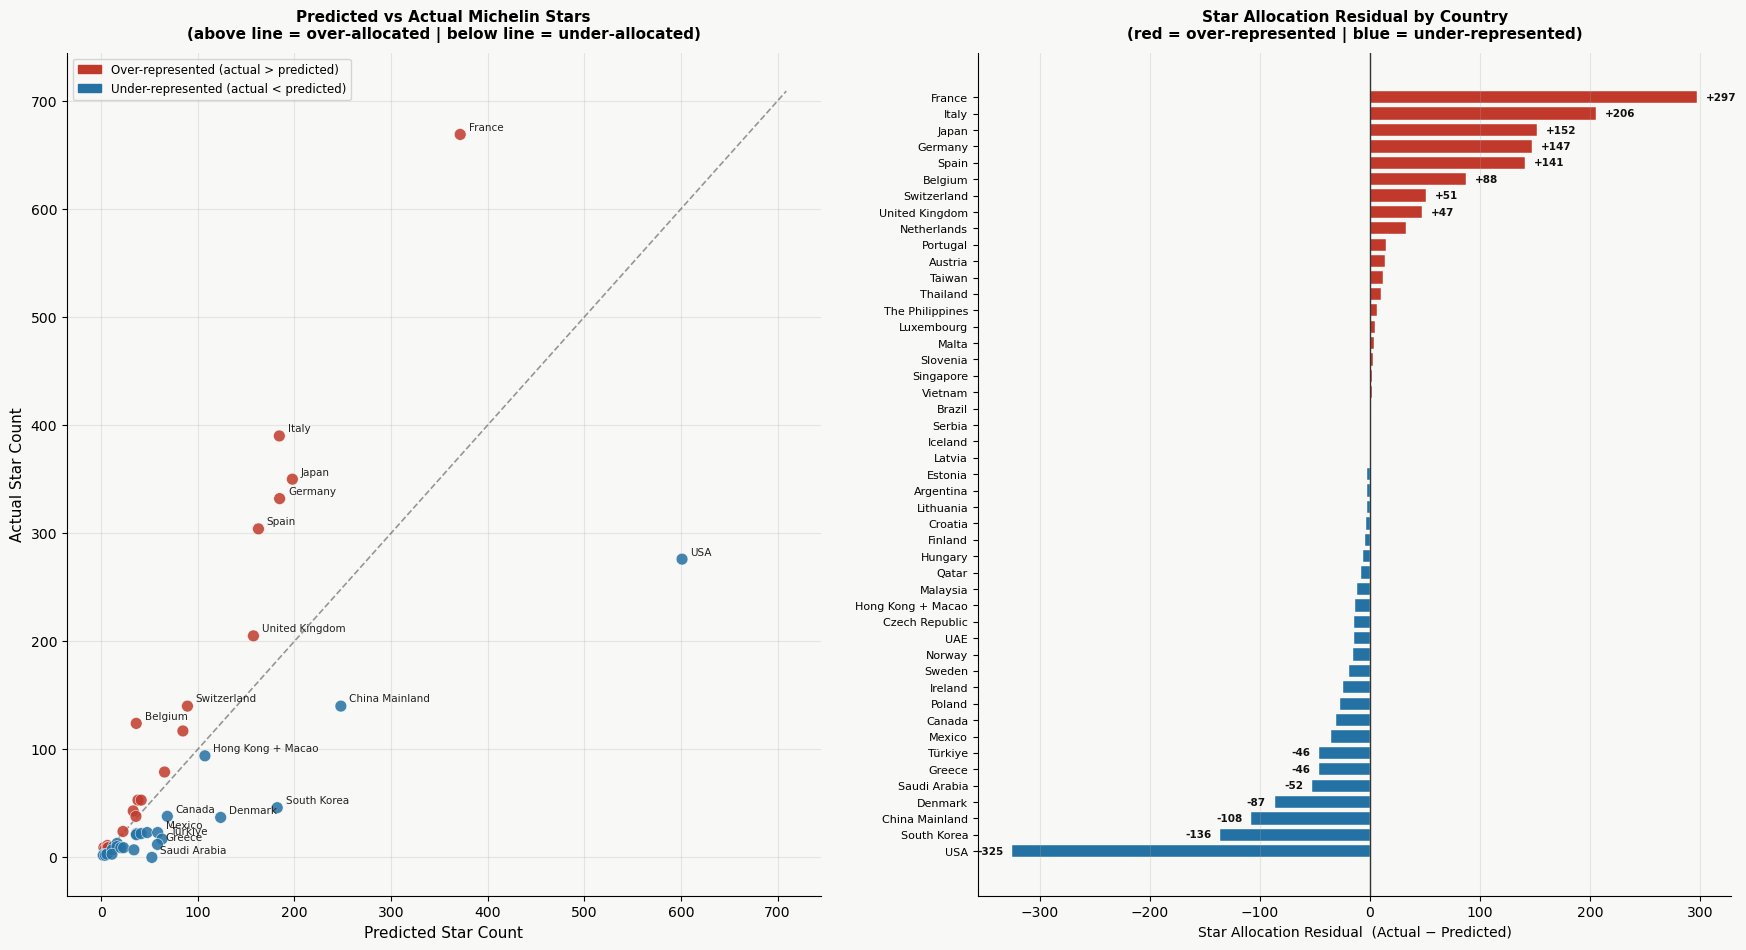

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.patch.set_facecolor('#f8f8f6')

# ── Plot 1: Predicted vs Actual ──────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#f8f8f6')

colors = ['#c0392b' if r > 0 else '#2471a3' for r in residuals_A['residual']]
ax1.scatter(residuals_A['predicted'], residuals_A['n_total_starred'],
            c=colors, s=72, alpha=0.85, zorder=3, edgecolors='white', linewidths=0.4)

# 45-degree reference line
mx = max(residuals_A['predicted'].max(), residuals_A['n_total_starred'].max()) * 1.06
ax1.plot([0, mx], [0, mx], color='#555', lw=1.2, ls='--', alpha=0.6, zorder=2, label='Perfect fit')

# Labels
label_these = ['France','Japan','Italy','Germany','USA','South Korea',
               'China Mainland','Denmark','Belgium','Switzerland','Spain',
               'Hong Kong + Macao','Türkiye','Greece','Canada','Mexico',
               'United Kingdom','Saudi Arabia']
for _, row in residuals_A.iterrows():
    if row['country'] in label_these:
        ax1.annotate(row['country'],
                     xy=(row['predicted'], row['n_total_starred']),
                     xytext=(6, 3), textcoords='offset points',
                     fontsize=7.5, color='#222', fontweight='500')

ax1.set_xlabel('Predicted Star Count', fontsize=11)
ax1.set_ylabel('Actual Star Count', fontsize=11)
ax1.set_title('Predicted vs Actual Michelin Stars\n'
              '(above line = over-allocated | below line = under-allocated)',
              fontsize=11, fontweight='bold', pad=10)
red_p  = mpatches.Patch(color='#c0392b', label='Over-represented (actual > predicted)')
blue_p = mpatches.Patch(color='#2471a3', label='Under-represented (actual < predicted)')
ax1.legend(handles=[red_p, blue_p], fontsize=8.5, loc='upper left')
ax1.grid(True, alpha=0.25, color='#aaa')
ax1.spines[['top','right']].set_visible(False)

# ── Plot 2: Residual bar chart ───────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#f8f8f6')

res_sorted  = residuals_A.sort_values('residual', ascending=True)
bar_colors  = ['#c0392b' if r > 0 else '#2471a3' for r in res_sorted['residual']]

ax2.barh(range(len(res_sorted)), res_sorted['residual'],
         color=bar_colors, edgecolor='white', linewidth=0.3, height=0.75)
ax2.set_yticks(range(len(res_sorted)))
ax2.set_yticklabels(res_sorted['country'], fontsize=8)
ax2.axvline(0, color='#333', lw=1.0, zorder=5)
ax2.set_xlabel('Star Allocation Residual  (Actual − Predicted)', fontsize=10)
ax2.set_title('Star Allocation Residual by Country\n'
              '(red = over-represented | blue = under-represented)',
              fontsize=11, fontweight='bold', pad=10)
ax2.grid(True, axis='x', alpha=0.25, color='#aaa')
ax2.spines[['top','right']].set_visible(False)

# Annotate large outliers
for i, (_, row) in enumerate(res_sorted.iterrows()):
    if abs(row['residual']) > 40:
        xpos = row['residual'] + (8 if row['residual'] > 0 else -8)
        ax2.text(xpos, i, f"{row['residual']:+.0f}",
                 va='center', ha='left' if row['residual'] > 0 else 'right',
                 fontsize=7.5, color='#111', fontweight='bold')

plt.tight_layout(pad=2.5)
plt.savefig('negbin_results.png', dpi=150, bbox_inches='tight', facecolor='#f8f8f6')
plt.show()

## 9. Key Findings

### 9.1 Which predictor is most statistically significant?

In [23]:
betas_A = res_A.x[:-1]
se_A_b  = se_A[:-1]
z_A     = betas_A / se_A_b
p_A     = 2 * (1 - zdist.cdf(np.abs(z_A)))

print("Predictor significance ranked by |z-score|:")
print(f"{'Variable':<26} {'|z|':>6}  {'p':>8}  {'Coef':>8}")
print("-" * 52)
order = np.argsort(-np.abs(z_A))
for i in order:
    print(f"  {feature_names[i]:<24} {abs(z_A[i]):>6.3f}  {p_A[i]:>8.4f}  {betas_A[i]:>+8.4f}")
print()
print("All three economic/market variables (log_tourism, log_restaurants, log_gdp)")
print("are highly significant (p < 0.001). Tourism arrivals has the highest z-score,")
print("followed closely by restaurant count and GDP per capita.")
print()
print("Urbanization rate and price floor are NOT significant after controlling")
print("for the economic variables — market wealth and size explain the lion's share.")

Predictor significance ranked by |z-score|:
Variable                      |z|         p      Coef
----------------------------------------------------
  Intercept                31.010    0.0000   +3.4991
  log_tourism (std)         4.930    0.0000   +0.7290
  log_restaurants (std)     4.628    0.0000   +0.8508
  log_gdp (std)             3.792    0.0001   +0.7222
  price_floor_usd (std)     1.345    0.1785   +0.2105
  urban_pct (std)           0.706    0.4805   +0.1099

All three economic/market variables (log_tourism, log_restaurants, log_gdp)
are highly significant (p < 0.001). Tourism arrivals has the highest z-score,
followed closely by restaurant count and GDP per capita.

Urbanization rate and price floor are NOT significant after controlling
for the economic variables — market wealth and size explain the lion's share.


### 9.2 Does France appear as an outlier?

In [25]:
france = residuals_A[residuals_A['country']=='France'].iloc[0]
print(f"France — Actual: {france['n_total_starred']:.0f}  "
      f"Predicted: {france['predicted']:.1f}  "
      f"Residual: {france['residual']:+.1f}")
print()
print(f"France's actual star count is {france['n_total_starred']/france['predicted']:.1f}x "
      f"its model-predicted count.")
print("It is the single largest positive outlier in the dataset — more stars than")
print("any economic or market variable predicts. This is consistent with France")
print("being Michelin's home market with over 120 years of guide history.")

France — Actual: 669  Predicted: 371.6  Residual: +297.4

France's actual star count is 1.8x its model-predicted count.
It is the single largest positive outlier in the dataset — more stars than
any economic or market variable predicts. This is consistent with France
being Michelin's home market with over 120 years of guide history.


### 9.3 Which non-European markets are most under-represented?

In [27]:
# European countries (rough list for filtering)
european = ['France','Spain','Italy','Germany','United Kingdom','Belgium',
            'Switzerland','Netherlands','Portugal','Austria','Ireland','Sweden',
            'Norway','Denmark','Finland','Iceland','Luxembourg','Poland',
            'Czech Republic','Hungary','Croatia','Slovenia','Estonia','Latvia',
            'Lithuania','Malta','Greece','Serbia','Türkiye']

non_eu = residuals_A[~residuals_A['country'].isin(european)].sort_values('residual')
print("Non-European markets ranked by residual (most under-represented first):")
print(f"{'Country':<24} {'Actual':>8} {'Predicted':>10} {'Residual':>10}")
print("-" * 56)
for _, row in non_eu.iterrows():
    print(f"  {row['country']:<22} {row['n_total_starred']:>8.0f} "
          f"{row['predicted']:>10.1f} {row['residual']:>+10.1f}")

Non-European markets ranked by residual (most under-represented first):
Country                    Actual  Predicted   Residual
--------------------------------------------------------
  USA                         276      601.2     -325.2
  South Korea                  46      182.2     -136.2
  China Mainland              140      248.1     -108.1
  Saudi Arabia                  0       52.5      -52.5
  Mexico                       23       58.5      -35.5
  Canada                       38       68.5      -30.5
  UAE                          22       36.6      -14.6
  Hong Kong + Macao            94      107.4      -13.4
  Malaysia                      9       20.3      -11.3
  Qatar                         3       11.2       -8.2
  Argentina                    10       12.7       -2.7
  Brazil                       24       22.6       +1.4
  Vietnam                       9        7.2       +1.8
  Singapore                    38       36.0       +2.0
  The Philippines              

### 9.4 What does the dispersion parameter tell us?

In [29]:
alpha_A = np.exp(res_A.x[-1])
alpha_B = np.exp(res_B.x[-1])

print(f"Dispersion parameter alpha:")
print(f"  Model A (all countries):          alpha = {alpha_A:.4f}")
print(f"  Model B (Saudi Arabia excluded):  alpha = {alpha_B:.4f}")
print()
print("Alpha = 0 would mean our structural variables perfectly explain all")
print(f"variance (Poisson case). Alpha = {alpha_A:.2f} is meaningfully large.")
print()
print("This tells us the model's five predictors — GDP, restaurant market size,")
print("tourism, urbanization, and price floor — capture a significant portion of")
print("the variation in star counts, but substantial unexplained variance remains.")
print()
print("That residual variance is the empirical space where Michelin's institutional")
print("history, cultural bias, and guide expansion strategy operate — it is not")
print("random noise, as the systematic pattern in the residuals (Europe over-represented,")
print("USA/South Korea/China under-represented) makes clear.")

Dispersion parameter alpha:
  Model A (all countries):          alpha = 0.5159
  Model B (Saudi Arabia excluded):  alpha = 0.4065

Alpha = 0 would mean our structural variables perfectly explain all
variance (Poisson case). Alpha = 0.52 is meaningfully large.

This tells us the model's five predictors — GDP, restaurant market size,
tourism, urbanization, and price floor — capture a significant portion of
the variation in star counts, but substantial unexplained variance remains.

That residual variance is the empirical space where Michelin's institutional
history, cultural bias, and guide expansion strategy operate — it is not
random noise, as the systematic pattern in the residuals (Europe over-represented,
USA/South Korea/China under-represented) makes clear.


## 10. Results Summary

### Interpretation for the paper

The negative binomial regression confirms that Michelin star allocation is meaningfully — but incompletely — explained by structural economic and market variables.

**Significant predictors (p < 0.001):** Log GDP per capita (β = 0.72), log restaurant market size (β = 0.85), and log inbound tourism (β = 0.73) each independently predict higher star counts after controlling for the others. Their standardized coefficients are comparable in magnitude, meaning no single factor dominates — economic capacity, dining market size, and visitor volume each contribute roughly equally.

**Non-significant predictors:** Urbanization rate (p = 0.48) and price floor (p = 0.18) add no explanatory power once the economic variables are included.

**Dispersion (alpha = 0.52):** Substantial unexplained variance remains after controlling for structural factors, indicating that something beyond economics drives Michelin's allocation decisions.

**The residuals tell the story:** The five most over-represented countries are France (+297), Italy (+206), Japan (+152), Germany (+147), and Spain (+141) — all legacy Michelin markets with decades of guide history. The five most under-represented are the USA (−325), South Korea (−136), China Mainland (−108), Denmark (−87), and Türkiye (−46). The USA result is the most striking: based on economic and market size, the model predicts 601 American stars; only 276 exist. That gap of 325 stars — larger than the entire star count of Italy — is the quantitative expression of Michelin's geographic bias.

**Robustness:** Excluding Saudi Arabia (a structural zero introduced by Michelin's very recent market entry) reduces alpha from 0.52 to 0.41 and shifts coefficients by no more than 0.03, confirming the core results are not driven by that single observation.